# 1. Yhdistäminen tietokantaan ja perustilastot

In [1]:
import sys
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from matplotlib.colors import LogNorm
from pathlib import Path

# 1. Lisätään projektin juurikansio polkuun, jotta config-tuonti onnistuu
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from config.store_config import store_config

# 2. Yhteys tietokantaan
# Notebook sijaitsee notebooks/-kansiossa, joten kanta on yksi taso ylempänä
con = duckdb.connect('../database/store.db')

# 3. Haetaan kaupan mitat
X_MAX = store_config["geometry"]["store_max_x_cm"]
Y_MAX = store_config["geometry"]["store_max_y_cm"]

print(f"✅ Yhteys muodostettu. Käytettävissä {X_MAX}x{Y_MAX} cm kokoinen myymäläalue.")

✅ Tiukennetut asetukset ladattu
✅ Yhteys muodostettu. Käytettävissä 10406x5220 cm kokoinen myymäläalue.


# 2. Kaupan käyttöaste tunneittain

/tmp/ipykernel_41678/1852046203.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_traffic, x='tunti', y='havainnot', palette='viridis')


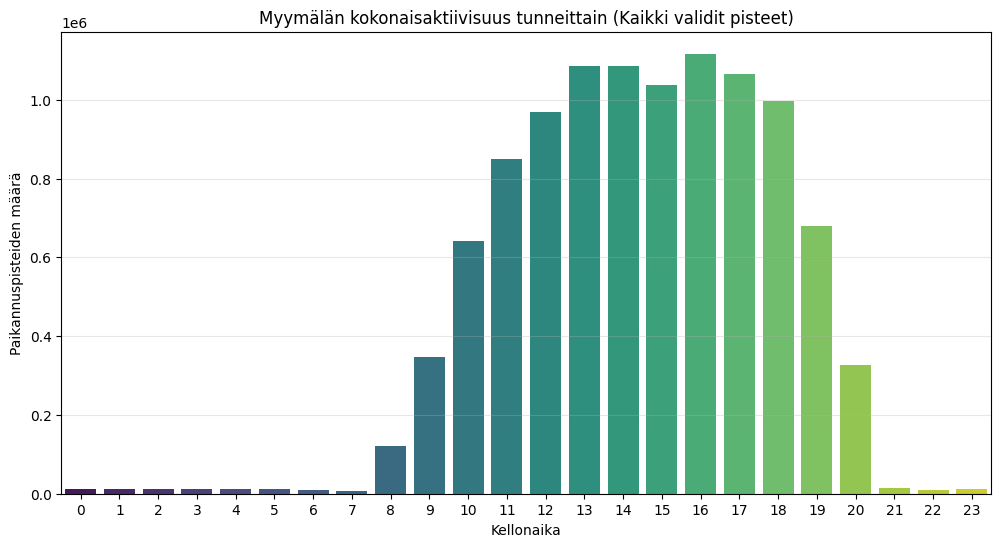

In [2]:
# Haetaan havaintojen määrä tunneittain
hourly_traffic = con.execute("""
    SELECT hour(timestamp) as tunti, count(*) as havainnot
    FROM Zone
    GROUP BY tunti
    ORDER BY tunti
""").df()

plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_traffic, x='tunti', y='havainnot', palette='viridis')
plt.title('Myymälän kokonaisaktiivisuus tunneittain (Kaikki validit pisteet)')
plt.xlabel('Kellonaika')
plt.ylabel('Paikannuspisteiden määrä')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Myymälän käyttöaste

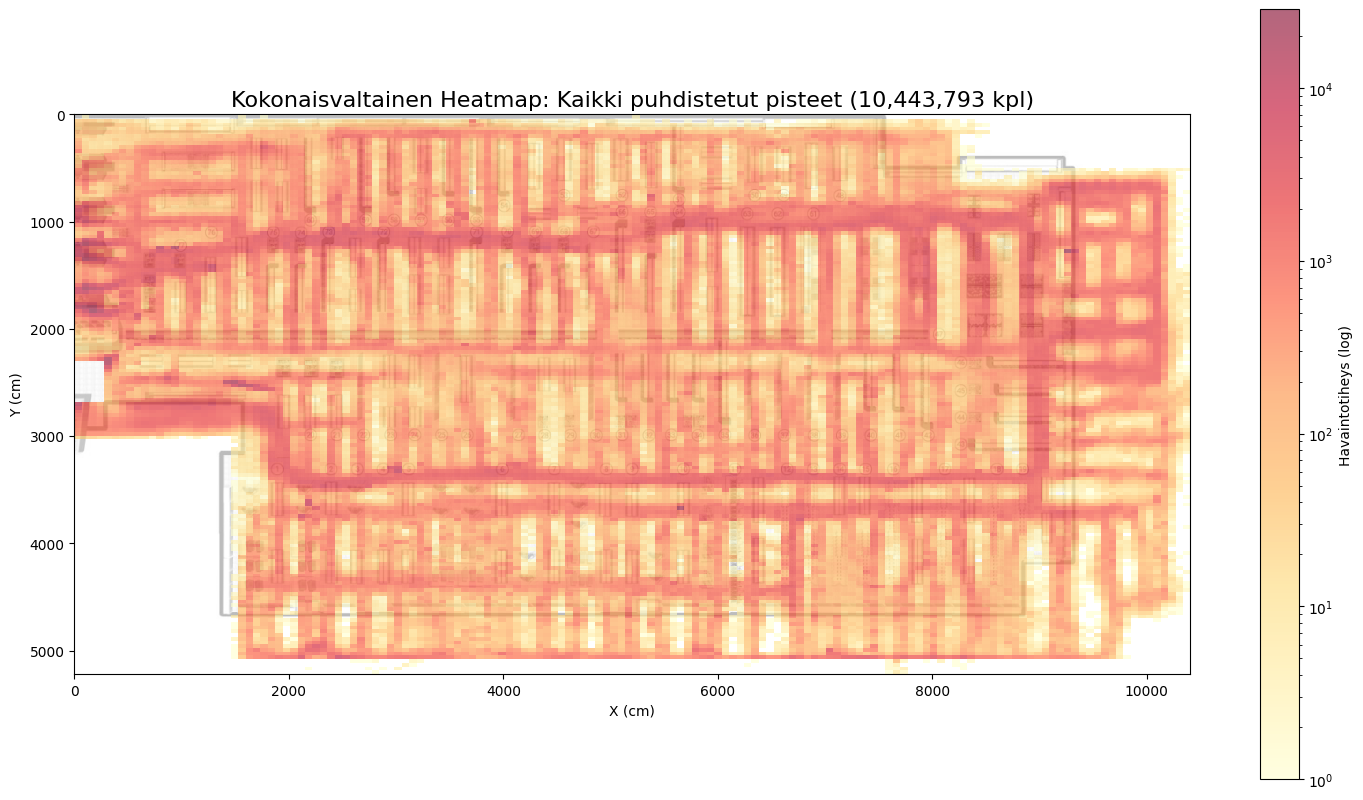

In [3]:
# 1. Haetaan kaikki puhdistetut koordinaatit
all_points = con.execute("SELECT x, y FROM Zone").df()

# 2. Valmistellaan taustakuva
img_path = '../kauppa.jpg'
if os.path.exists(img_path):
    img = Image.open(img_path)
    img_cfg = store_config["geometry"]["image"]
    
    # Lasketaan kuvan skaala ja ulottuvuus (Extent)
    scale = X_MAX / img_cfg["width_px"]
    img_x_min = -img_cfg["origin_x_px"] * scale
    img_x_max = (img_cfg["width_px"] - img_cfg["origin_x_px"]) * scale
    img_y_min = -img_cfg["origin_y_px"] * scale
    img_y_max = (img_cfg["height_px"] - img_cfg["origin_y_px"]) * scale
    EXT = [img_x_min, img_x_max, img_y_max, img_y_min]

    # 3. Piirretään heatmap
    fig, ax = plt.subplots(figsize=(18, 10))
    
    # Taustakuva
    ax.imshow(img, extent=EXT, aspect='equal', alpha=0.5)
    
    # Heatmap (hist2d)
    # LogNorm auttaa näkemään erot, vaikka joissain kohdissa olisi todella paljon dataa
    h = ax.hist2d(all_points['x'], all_points['y'], bins=150, 
                  cmap='YlOrRd', norm=LogNorm(), alpha=0.6)
    
    plt.colorbar(h[3], ax=ax, label='Havaintotiheys (log)')
    
    # Rajataan näkymä myymälän koordinaatteihin
    ax.set_xlim(0, X_MAX)
    ax.set_ylim(Y_MAX, 0) # Invert Y: 0 on ylhäällä
    
    plt.title(f"Kokonaisvaltainen Heatmap: Kaikki puhdistetut pisteet ({len(all_points):,} kpl)", fontsize=16)
    plt.xlabel("X (cm)")
    plt.ylabel("Y (cm)")
    plt.show()
else:
    print(f"⚠️ Kuvaa {img_path} ei löytynyt. Piirretään ilman taustaa.")

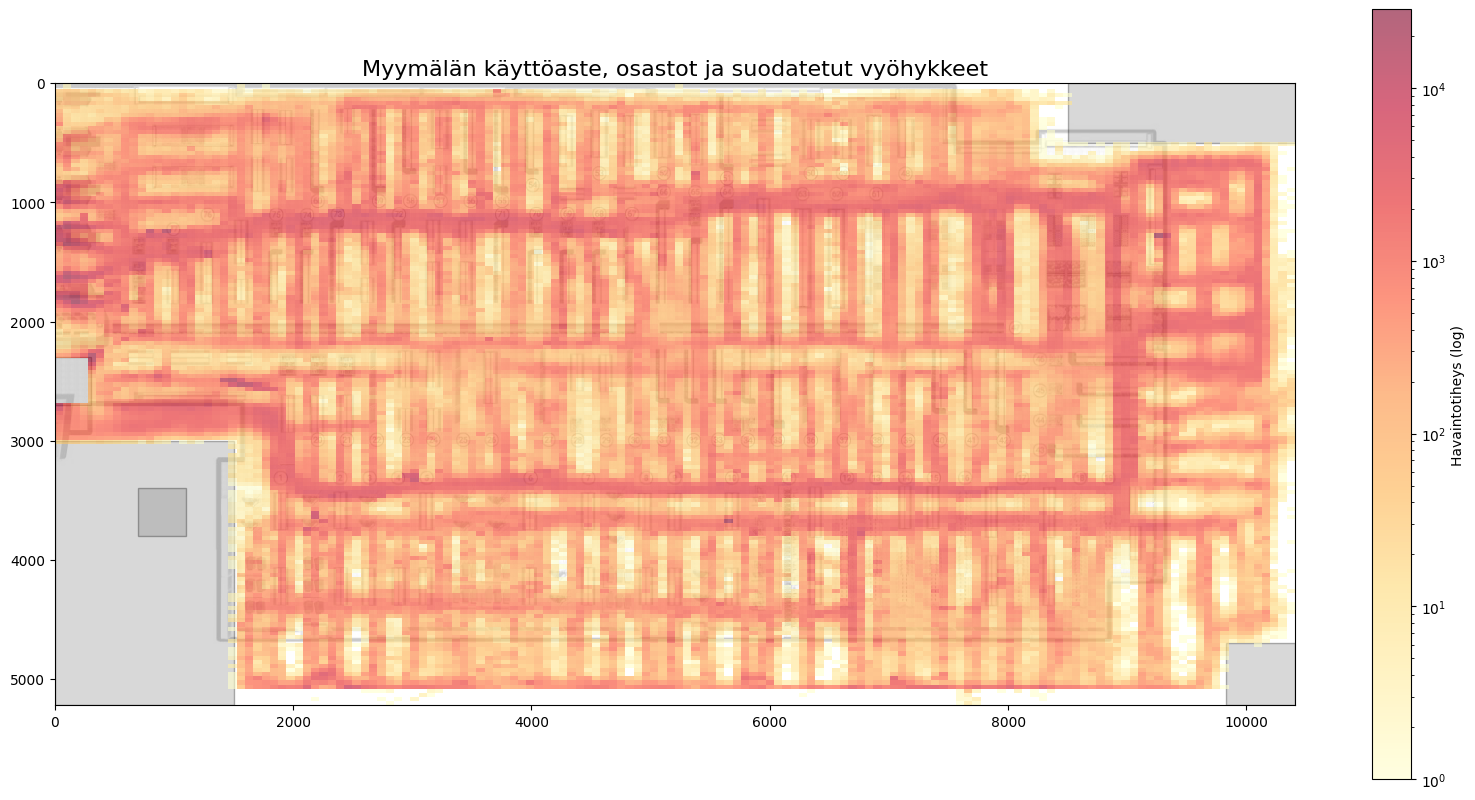

In [4]:
import matplotlib.patches as patches

# 1. Haetaan data ja kuva (kuten aiemmin)
all_points = con.execute("SELECT x, y FROM Zone").df()
img = Image.open('../kauppa.jpg')
img_cfg = store_config["geometry"]["image"]

# 2. Lasketaan kuvan sijoittelu
scale = X_MAX / img_cfg["width_px"]
EXT = [
    -img_cfg["origin_x_px"] * scale,
    (img_cfg["width_px"] - img_cfg["origin_x_px"]) * scale,
    (img_cfg["height_px"] - img_cfg["origin_y_px"]) * scale,
    -img_cfg["origin_y_px"] * scale
]

fig, ax = plt.subplots(figsize=(20, 10))
ax.imshow(img, extent=EXT, aspect='equal', alpha=0.4)

# 3. PIIRRETÄÄN MUUT RAJATUT ALUEET (Faktat config-tiedostosta)

# A. Piirretään "Dead Zones" (alueet joista data on suodatettu pois)
if "spatial_zones" in store_config and "dead_zones" in store_config["spatial_zones"]:
    for name, coords in store_config["spatial_zones"]["dead_zones"].items():
        # coords = [x_min, x_max, y_min, y_max]
        rect = patches.Rectangle(
            (coords[0], coords[2]), 
            coords[1] - coords[0], 
            coords[3] - coords[2],
            linewidth=1, edgecolor='black', facecolor='grey', alpha=0.3, label='Dead Zone'
        )
        ax.add_patch(rect)

# B. Piirretään Myymälän osastot / Kategoriat
# Huom: Tämä olettaa että kategoriat on määritetty configissa tai haetaan kannasta
# Jos kategoriat ovat Categories-taulussa:
categories = con.execute("SELECT * FROM Categories").df()
for _, cat in categories.iterrows():
    rect = patches.Rectangle(
        (cat['x_min'], cat['y_min']), 
        cat['x_max'] - cat['x_min'], 
        cat['y_max'] - cat['y_min'],
        linewidth=2, edgecolor='blue', facecolor='none', alpha=0.8
    )
    ax.add_patch(rect)
    ax.text(cat['x_min'], cat['y_min'] - 5, cat['name'], color='blue', fontsize=9, fontweight='bold')

# 4. Heatmap
h = ax.hist2d(all_points['x'], all_points['y'], bins=150, 
              cmap='YlOrRd', norm=LogNorm(), alpha=0.6)

plt.colorbar(h[3], ax=ax, label='Havaintotiheys (log)')
ax.set_xlim(0, X_MAX)
ax.set_ylim(Y_MAX, 0)
plt.title("Myymälän käyttöaste, osastot ja suodatetut vyöhykkeet", fontsize=16)
plt.show()